In [1]:
from sklearn.metrics import *
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_smoothing_spline

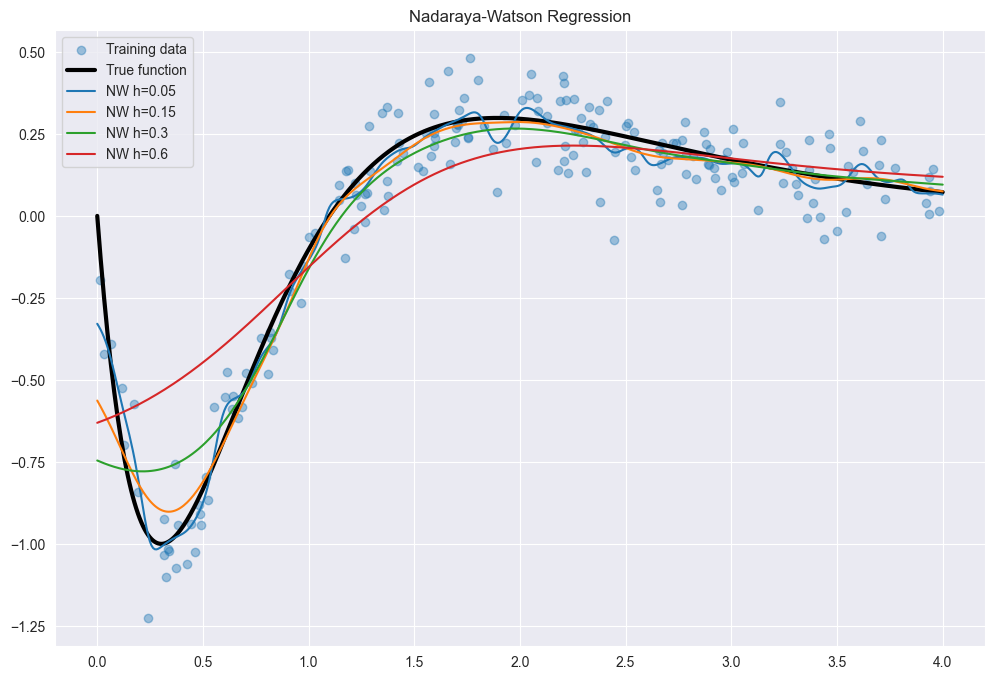

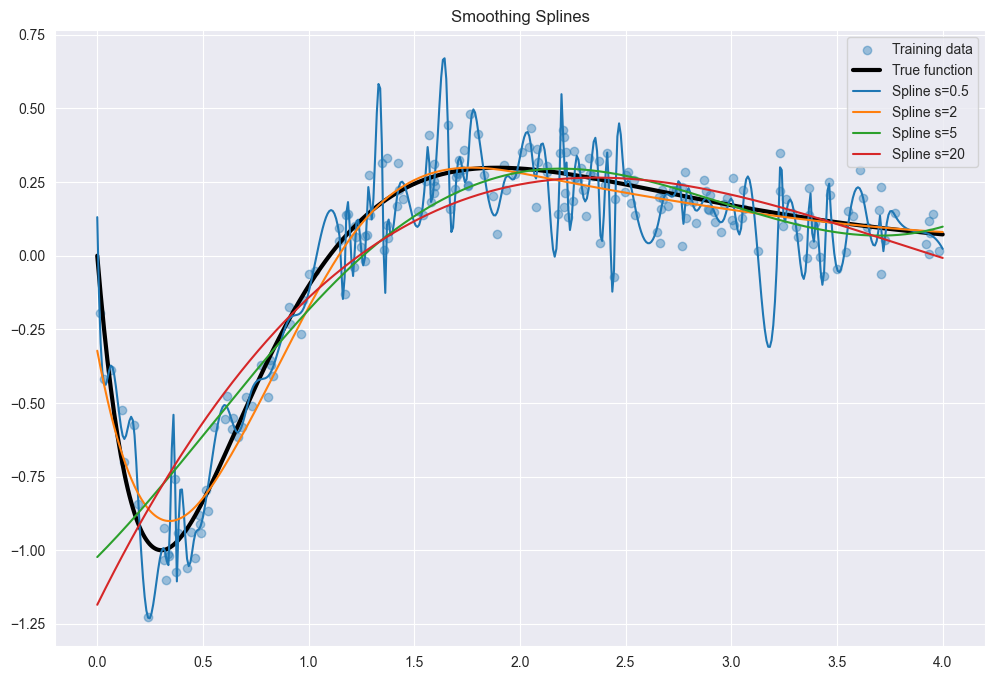


NADARAYA-WATSON RESULTS
------------------------------------------------------------

h = 0.05
train_MSEg     : 0.001624
train_MSEy     : 0.007119
test_MSEg      : 0.002112
test_MSEy      : 0.011773

h = 0.15
train_MSEg     : 0.003023
train_MSEy     : 0.010504
test_MSEg      : 0.004365
test_MSEy      : 0.014057

h = 0.3
train_MSEg     : 0.008364
train_MSEy     : 0.015914
test_MSEg      : 0.011035
test_MSEy      : 0.020809

h = 0.6
train_MSEg     : 0.027978
train_MSEy     : 0.034967
test_MSEg      : 0.029533
test_MSEy      : 0.039582


SMOOTHING SPLINE RESULTS
------------------------------------------------------------

s = 0.5
train_MSEg     : 0.006666
train_MSEy     : 0.002501
test_MSEg      : 0.015039
test_MSEy      : 0.024884

s = 2
train_MSEg     : 0.001894
train_MSEy     : 0.009997
test_MSEg      : 0.002560
test_MSEy      : 0.012359

s = 5
train_MSEg     : 0.017321
train_MSEy     : 0.024995
test_MSEg      : 0.022640
test_MSEy      : 0.032121

s = 20
train_MSEg     : 0.023793
tra

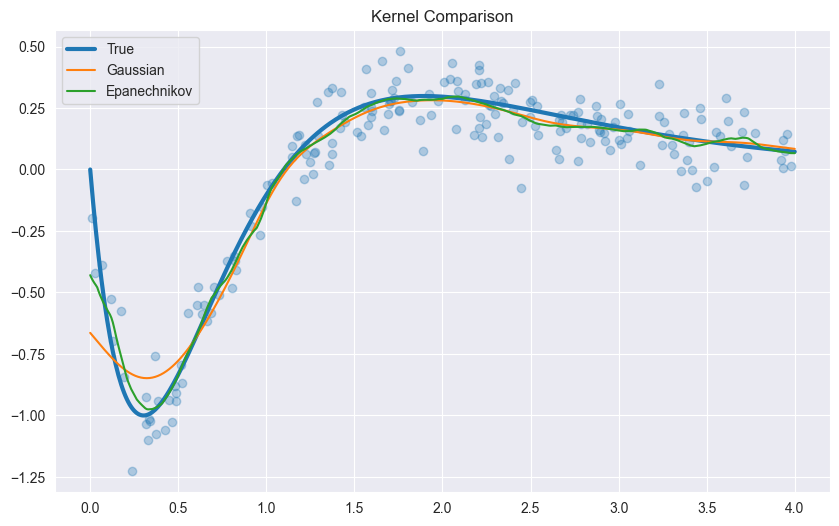

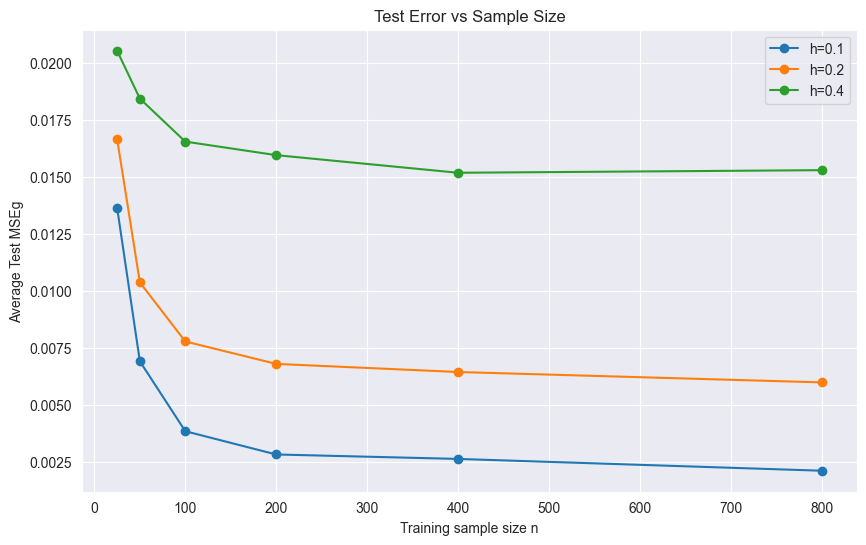

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline

# ============================================================
# 1. DATA GENERATION
# ============================================================

np.random.seed(123)

sigma = 0.1

def g(x):
    return 4.26 * (np.exp(-x) - 4*np.exp(-2*x) + 3*np.exp(-3*x))

def generate_data(n):
    x = np.random.uniform(0, 4, n)
    eps = np.random.normal(0, sigma, n)
    y = g(x) + eps
    return x, y

n_train = 200
n_test = 1000

x_train, y_train = generate_data(n_train)
x_test, y_test = generate_data(n_test)

# ============================================================
# 2. NADARAYA-WATSON REGRESSION (FROM SCRATCH)
# ============================================================

def gaussian_kernel(u):
    return (1 / np.sqrt(2*np.pi)) * np.exp(-0.5 * u**2)

def epanechnikov_kernel(u):
    out = np.zeros_like(u)
    mask = np.abs(u) <= 1
    out[mask] = 0.75 * (1 - u[mask]**2)
    return out

def nadaraya_watson(x_eval, x_train, y_train, h, kernel):
    y_hat = np.zeros(len(x_eval))

    for j, x in enumerate(x_eval):
        weights = kernel((x - x_train) / h)

        if np.sum(weights) == 0:
            y_hat[j] = np.mean(y_train)
        else:
            y_hat[j] = np.sum(weights * y_train) / np.sum(weights)

    return y_hat

# ============================================================
# 3. ERROR MEASURES
# ============================================================

def mse_g(x, y_hat):
    return np.mean((g(x) - y_hat)**2)

def mse_y(y, y_hat):
    return np.mean((y - y_hat)**2)

# ============================================================
# 4. FITTING DIFFERENT BANDWIDTHS
# ============================================================

bandwidths = [0.05, 0.15, 0.30, 0.60]

x_grid = np.linspace(0, 4, 500)

plt.figure(figsize=(12, 8))
plt.scatter(x_train, y_train,
            alpha=0.4,
            label='Training data')

plt.plot(x_grid,
         g(x_grid),
         'k',
         linewidth=3,
         label='True function')

nw_results = {}

for h in bandwidths:

    y_grid = nadaraya_watson(
        x_grid,
        x_train,
        y_train,
        h,
        gaussian_kernel
    )

    plt.plot(x_grid,
             y_grid,
             label=f'NW h={h}')

    train_pred = nadaraya_watson(
        x_train,
        x_train,
        y_train,
        h,
        gaussian_kernel
    )

    test_pred = nadaraya_watson(
        x_test,
        x_train,
        y_train,
        h,
        gaussian_kernel
    )

    nw_results[h] = {
        "train_MSEg": mse_g(x_train, train_pred),
        "train_MSEy": mse_y(y_train, train_pred),
        "test_MSEg": mse_g(x_test, test_pred),
        "test_MSEy": mse_y(y_test, test_pred)
    }

plt.title("Nadaraya-Watson Regression")
plt.legend()
plt.show()

# ============================================================
# 5. SMOOTHING SPLINES
# ============================================================

order = np.argsort(x_train)

x_sorted = x_train[order]
y_sorted = y_train[order]

s_values = [0.5, 2, 5, 20]

plt.figure(figsize=(12, 8))
plt.scatter(x_train,
            y_train,
            alpha=0.4,
            label='Training data')

plt.plot(x_grid,
         g(x_grid),
         'k',
         linewidth=3,
         label='True function')

spline_results = {}

for s in s_values:

    spline = UnivariateSpline(
        x_sorted,
        y_sorted,
        s=s
    )

    plt.plot(
        x_grid,
        spline(x_grid),
        label=f'Spline s={s}'
    )

    train_pred = spline(x_train)
    test_pred = spline(x_test)

    spline_results[s] = {
        "train_MSEg": mse_g(x_train, train_pred),
        "train_MSEy": mse_y(y_train, train_pred),
        "test_MSEg": mse_g(x_test, test_pred),
        "test_MSEy": mse_y(y_test, test_pred)
    }

plt.title("Smoothing Splines")
plt.legend()
plt.show()

# ============================================================
# 6. PRINT ERROR TABLES
# ============================================================

print("\nNADARAYA-WATSON RESULTS")
print("-"*60)

for h, res in nw_results.items():
    print(f"\nh = {h}")
    for key, value in res.items():
        print(f"{key:15s}: {value:.6f}")

print("\n\nSMOOTHING SPLINE RESULTS")
print("-"*60)

for s, res in spline_results.items():
    print(f"\ns = {s}")
    for key, value in res.items():
        print(f"{key:15s}: {value:.6f}")

# ============================================================
# 7. COMPARE GAUSSIAN VS EPANECHNIKOV KERNEL
# ============================================================

h = 0.20

gauss_fit = nadaraya_watson(
    x_grid,
    x_train,
    y_train,
    h,
    gaussian_kernel
)

epa_fit = nadaraya_watson(
    x_grid,
    x_train,
    y_train,
    h,
    epanechnikov_kernel
)

plt.figure(figsize=(10, 6))

plt.scatter(x_train, y_train, alpha=0.3)

plt.plot(x_grid,
         g(x_grid),
         linewidth=3,
         label='True')

plt.plot(x_grid,
         gauss_fit,
         label='Gaussian')

plt.plot(x_grid,
         epa_fit,
         label='Epanechnikov')

plt.title("Kernel Comparison")
plt.legend()
plt.show()

# ============================================================
# 8. TEST ERROR VS SAMPLE SIZE
# ============================================================

sample_sizes = [25, 50, 100, 200, 400, 800]
repetitions = 50

bandwidths = [0.10, 0.20, 0.40]

avg_errors = {h: [] for h in bandwidths}

for n in sample_sizes:

    for h in bandwidths:

        errs = []

        for _ in range(repetitions):

            x_train, y_train = generate_data(n)
            x_test, y_test = generate_data(1000)

            pred = nadaraya_watson(
                x_test,
                x_train,
                y_train,
                h,
                gaussian_kernel
            )

            errs.append(mse_g(x_test, pred))

        avg_errors[h].append(np.mean(errs))

plt.figure(figsize=(10, 6))

for h in bandwidths:
    plt.plot(sample_sizes,
             avg_errors[h],
             marker='o',
             label=f'h={h}')

plt.xlabel("Training sample size n")
plt.ylabel("Average Test MSEg")
plt.title("Test Error vs Sample Size")
plt.legend()
plt.grid(True)
plt.show()

In [2]:
def auxil_function(x):
    return 4.26*(np.exp(-x)-4*np.exp(-2*x)+3*np.exp(-3*x))
def generator(n):
    x=np.random.uniform(0,4,n)
    eps=np.random.normal(0,0.01,n)
    y=auxil_function(x)+eps
    return x,y


In [ ]:
def NDEstimator(x_0,x,y,h,kernel="gaussian"):
    numerator=0
    denominator=0
    for i in range(len(y)):
        if kernel=="gaussian":
            k=((x-x_0)/h) #add gaussian kernel as function
            numerator=numerator+k*y[i]
            denominator=denominator+k
        else:
            raise ValueError(f"provided kernel {kernel} is not supported!")
    y_0=numerator/denominator
    return y_0

In [7]:
x_train,y_train=generator(100)

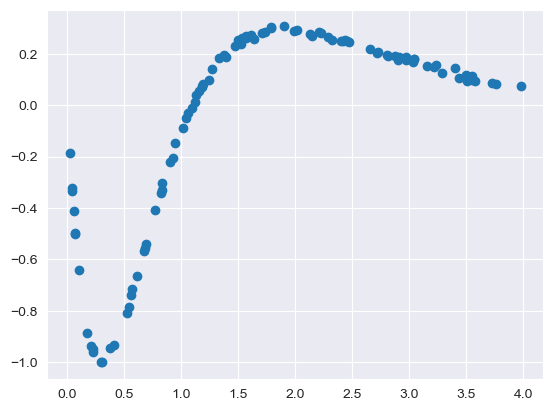

In [8]:
plt.scatter(x_train,y_train)